Автоматизация докера

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import re
import json
import base64
import subprocess
import time
from pathlib import Path

from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
from IPython.display import Image, display, HTML

In [4]:
# ── Настройка директорий ──────────────────────────────────────────────────────
OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "../scripts/demo_05"))
DOCKER_DIR = OUTPUT_DIR / "docker"

if OUTPUT_DIR.exists():
    for f in OUTPUT_DIR.iterdir():
        if f.is_file():
            f.unlink()
    print(f"🗑️  Папка очищена: {OUTPUT_DIR}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if DOCKER_DIR.exists():
    for f in DOCKER_DIR.iterdir():
        if f.is_file():
            f.unlink()
    print(f"🗑️  Папка очищена: {DOCKER_DIR}")
DOCKER_DIR.mkdir(parents=True, exist_ok=True)

# ── Модель ────────────────────────────────────────────────────────────────────
model = ChatOpenAI(
    base_url=os.getenv("OPENAI_API_HOST"),
    api_key=os.getenv("OPENAI_API_KEY"),
    model="Qwen/Qwen3.5-27B",
    timeout=120,
    temperature=0.7,
    extra_body={"chat_template_kwargs": {"enable_thinking": False}},
)

# ── Утилиты ───────────────────────────────────────────────────────────────────
def extract_filename(text: str) -> str | None:
    match = re.search(
        r'[\w\-]+\.(html|css|js|json|md|txt|yml|yaml|env|example|dockerignore)|Dockerfile',
        text, re.IGNORECASE)
    return match.group(0) if match else None

def save_file(filename: str, content: str) -> str:
    content = re.sub(r'^```[\w]*\n?', '', content.strip())
    content = re.sub(r'\n?```$', '', content.strip())
    filepath = OUTPUT_DIR / filename
    filepath.write_text(content, encoding="utf-8")
    print(f"   💾 Сохранено: {filepath}")
    return str(filepath)

def save_file_docker(filename: str, content: str) -> str:
    content = re.sub(r'^```[\w]*\n?', '', content.strip())
    content = re.sub(r'\n?```$', '', content.strip())
    filepath = DOCKER_DIR / filename
    filepath.write_text(content, encoding="utf-8")
    print(f"   💾 Сохранено: {filepath}")
    return str(filepath)

def run_cmd(cmd: str, cwd: Path = None) -> tuple[int, str, str]:
    result = subprocess.run(
        cmd, shell=True, cwd=cwd,
        capture_output=True, text=True
    )
    return result.returncode, result.stdout.strip(), result.stderr.strip()

# ── Retry-обёртка для вызовов модели ─────────────────────────────────────────
def invoke_with_retry(messages, retries: int = 3, delay: int = 5) -> str:
    """Вызвать модель с повторными попытками при обрыве соединения."""
    for attempt in range(1, retries + 1):
        try:
            result = model.invoke(messages)
            return result.content
        except Exception as e:
            err_str = str(e)
            if attempt < retries and any(x in err_str for x in [
                "Connection error", "RemoteProtocolError",
                "Server disconnected", "APIConnectionError"
            ]):
                print(f"   ⚠️  Обрыв соединения (попытка {attempt}/{retries}), жду {delay}с...")
                time.sleep(delay)
            else:
                raise
    raise RuntimeError("Превышено число попыток подключения к API")

# ── Инструменты planner_agent ─────────────────────────────────────────────────

@tool
def create_plan(query: str) -> str:
    """Создать план разработки веб-приложения. Возвращает JSON-список файлов."""
    messages = [
        SystemMessage(content="""Ты — старший планировщик проектов.
Разбей задачу на конкретные файлы. Отвечай ТОЛЬКО валидным JSON массивом.
Каждый элемент: {"filename": "имя файла", "description": "что должно быть внутри"}

ВАЖНО:
- каждый файл ровно один раз
- максимум один js-файл (main.js)
- сначала index.html со всеми id-элементами
- в описаниях css/js указывай какие id/классы использовать из index.html
- в main.js разработчик получит API ключ через инструмент get_api_key
"""),
        HumanMessage(content=query)
    ]
    plan = invoke_with_retry(messages)
    print(f'{plan=}')
    return plan

# ── Инструменты developer_agent ───────────────────────────────────────────────

@tool
def write_file(description: str) -> str:
    """Написать содержимое одного файла по его описанию. Возвращает готовый код."""
    messages = [
        SystemMessage(content="""Ты — старший веб-разработчик.
Получаешь описание файла — возвращаешь ТОЛЬКО готовое содержимое файла.
Никаких пояснений, никакого markdown."""),
        HumanMessage(content=description)
    ]
    return invoke_with_retry(messages)

@tool
def get_api_key() -> str:
    """
    Получить API ключ для OpenWeatherMap в зашифрованном виде.
    Используй когда нужно вставить API_KEY в main.js.
    """
    raw_key = os.getenv("WEATHER_API_KEY", "")
    if not raw_key:
        return "Ошибка: WEATHER_API_KEY не найден в .env"
    encoded = base64.b64encode(raw_key.encode()).decode()
    js_snippet = f"""// Вставь этот код в начало main.js:
const _k = atob("{encoded}");
// Используй _k вместо API_KEY в запросах к OpenWeatherMap
"""
    print(f"   🔑 [get_api_key] Ключ зашифрован и передан разработчику")
    return js_snippet

@tool
def save_project_file(filename: str, content: str) -> str:
    """Сохранить файл проекта на диск."""
    saved = save_file(filename, content)
    return f"Файл {filename} сохранён: {saved}"

# ── Инструменты docker_developer_agent ───────────────────────────────────────

@tool
def write_docker_file(filename: str, description: str) -> str:
    """
    Написать содержимое одного Docker-файла.
    Аргументы: filename — имя файла, description — подробное ТЗ.
    """

    # ── Dockerfile и docker-compose пишем жёстко — модели не доверяем ────────
    HARDCODED = {
        "Dockerfile": (
            "FROM nginx:1.27-alpine"
            "COPY . /usr/share/nginx/html\n"
            "EXPOSE 80\n"
        ),
        "docker-compose.yml": (
            'version: "3.9"\n\n'
            "services:\n"
            "  weather-app:\n"
            "    build:\n"
            "      context: ..\n"
            "      dockerfile: docker/Dockerfile\n"
            "    ports:\n"
            '      - "8080:80"\n'
            "    restart: always\n"
        ),
    }

    if filename in HARDCODED:
        content = HARDCODED[filename]
        print(f"   ✍️  {filename}: использован жёсткий шаблон ({len(content)} символов)")
        return content

    # Остальные файлы (.env.example, .dockerignore) — генерирует модель
    messages = [
        SystemMessage(content="""Ты — Senior DevOps инженер.
Возвращаешь ТОЛЬКО содержимое файла. Никакого markdown, никаких ```."""),
        HumanMessage(content=f"Файл: {filename}\nОписание: {description}")
    ]
    content = invoke_with_retry(messages)
    content = re.sub(r'^```[\w]*\n?', '', content.strip())
    content = re.sub(r'\n?```$', '', content.strip())
    print(f"   ✍️  {filename}: написан ({len(content)} символов)")
    return content

@tool
def save_docker_file(filename: str, content: str) -> str:
    """Сохранить Docker-файл на диск в папку docker."""
    saved = save_file_docker(filename, content)
    return f"Файл {filename} сохранён: {saved}"

# ── Инструменты deploy_agent ──────────────────────────────────────────────────

@tool
def stop_and_remove_containers(placeholder: str = "") -> str:
    """Остановить и удалить все контейнеры текущего проекта. Передай пустую строку."""
    print(f"\n🛑 [Deploy] Останавливаю контейнеры...")
    abs_docker_dir = DOCKER_DIR.resolve()

    code, out, err = run_cmd("docker-compose down --remove-orphans", cwd=abs_docker_dir)
    if code == 0:
        print(f"   ✅ Контейнеры остановлены")
    else:
        print(f"   ⚠️  {err}")

    code2, out2, _ = run_cmd("docker ps -q --filter name=weather-app")
    if out2:
        run_cmd(f"docker rm -f {out2}")
        print(f"   ✅ Принудительно удалён: {out2}")

    return "Контейнеры остановлены и удалены"


@tool
def build_and_run_docker(placeholder: str = "") -> str:
    """Собрать образ и запустить контейнер. Передай пустую строку."""
    print(f"\n🐳 [Deploy] Собираю и запускаю контейнер...")

    abs_docker_dir = DOCKER_DIR.resolve()
    abs_output_dir = OUTPUT_DIR.resolve()
    compose_file = abs_docker_dir / "docker-compose.yml"
    dockerfile = abs_docker_dir / "Dockerfile"

    # Проверка файлов
    if not compose_file.exists():
        return f"❌ Ошибка: docker-compose.yml не найден в {abs_docker_dir}"
    if not dockerfile.exists():
        return f"❌ Ошибка: Dockerfile не найден в {abs_docker_dir}"

    print(f"   📂 DOCKER_DIR : {abs_docker_dir}")
    print(f"   📂 OUTPUT_DIR : {abs_output_dir}")
    print(f"   📄 Dockerfile :\n{dockerfile.read_text()}")
    print(f"   📄 docker-compose.yml :\n{compose_file.read_text()}")

    # Сборка
    print(f"\n   🔨 Сборка образа...")
    code, out, err = run_cmd("docker-compose build --no-cache", cwd=abs_docker_dir)
    print(f"   stdout: {out[:300]}")
    if code != 0:
        print(f"   stderr: {err[:500]}")
        return f"❌ Ошибка сборки:\n{err}"
    print(f"   ✅ Образ собран")

    # Запуск
    print(f"\n   🚀 Запуск контейнера...")
    code, out, err = run_cmd("docker-compose up -d", cwd=abs_docker_dir)
    if code != 0:
        print(f"   stderr: {err[:500]}")
        return f"❌ Ошибка запуска:\n{err}"
    print(f"   ✅ Контейнер запущен")

    # Получить порт
    code, port_out, _ = run_cmd("docker-compose port weather-app 80", cwd=abs_docker_dir)
    port = port_out.split(":")[-1] if ":" in port_out else "8080"
    url = f"http://localhost:{port}"
    print(f"   🌐 URL: {url}")
    return f"✅ Контейнер запущен. URL: {url}"


@tool
def check_container_status(placeholder: str = "") -> str:
    """Проверить статус контейнеров. Передай пустую строку."""
    code, out, err = run_cmd("docker-compose ps", cwd=DOCKER_DIR.resolve())
    if code != 0:
        return f"Ошибка: {err}"
    return out if out else "Контейнеры не запущены"

# ── Агенты ────────────────────────────────────────────────────────────────────

planner_agent = create_react_agent(
    model=model,
    tools=[create_plan],
    prompt="Ты — агент-планировщик. Вызови create_plan и верни JSON-план файлов проекта.",
    name="planner_agent",
)

developer_agent = create_react_agent(
    model=model,
    tools=[write_file, save_project_file, get_api_key],
    prompt="""Ты — агент-разработчик. Получаешь план в виде JSON-списка файлов.
Для каждого файла:
1. Если файл main.js — сначала вызови get_api_key чтобы получить зашифрованный ключ
2. Вызови write_file с описанием файла (включи в описание полученный js_snippet)
3. Вызови save_project_file с именем файла и содержимым
Обработай ВСЕ файлы из плана.""",
    name="developer_agent",
)

executor_agent = create_react_agent(
    model=model,
    tools=[write_docker_file, save_docker_file],
    prompt="""Ты — DevOps-разработчик. Создай файлы для Docker-деплоя.

Создай СТРОГО ЭТИ файлы по порядку, для каждого:
1. Вызови write_docker_file(filename, description)
2. Вызови save_docker_file(filename, content)

Список файлов:
- filename: "Dockerfile"
  description: "Контейнер для раздачи статических файлов (html, css, js). 
  Контекст сборки — папка с фронтендом."

- filename: "docker-compose.yml"
  description: "Запуск контейнера weather-app, порт 8080, 
  context: .. , dockerfile: docker/Dockerfile, restart: always"

- filename: ".env.example"
  description: "OPENAI_API_HOST, OPENAI_API_KEY, WEATHER_API_KEY с пустыми значениями"

- filename: ".dockerignore"
  description: ".env, .git, __pycache__, *.pyc, docker/"

Обработай ВСЕ 4 файла.""",
    name="executor_agent",
)

deploy_agent = create_react_agent(
    model=model,
    tools=[stop_and_remove_containers, build_and_run_docker, check_container_status],
    prompt="""Ты — агент деплоя. Выполни строго по порядку:
1. stop_and_remove_containers("") — останови старые контейнеры
2. build_and_run_docker("") — собери и запусти новый контейнер
3. check_container_status("") — проверь что контейнер работает
Верни итоговый URL приложения.""",
    name="deploy_agent",
)

# ── Supervisor ────────────────────────────────────────────────────────────────

workflow = create_supervisor(
    agents=[planner_agent, developer_agent, executor_agent, deploy_agent],
    model=model,
    prompt="""Ты — менеджер команды разработки. Выполняй СТРОГО по порядку:

1. planner_agent          — составит план файлов проекта
2. developer_agent        — напишет и сохранит файлы фронтенда
3. executor_agent — создаст Dockerfile и docker-compose.yml
4. deploy_agent           — остановит старые контейнеры, соберёт и запустит новый

НЕ пропускай ни одного агента.
НЕ завершай работу пока все четыре агента не выполнены.
В финальном ответе обязательно укажи URL приложения."""
)

app = workflow.compile()

# ── Запуск ────────────────────────────────────────────────────────────────────

query = """Создай веб-приложение, которое показывает погоду в Москве
на ближайшие 3 дня. Данные бери с openweathermap.org."""

print("\nЗапуск мультиагентной системы (LangGraph Supervisor)...")
print("=" * 60)

result = app.invoke(
    {"messages": [{"role": "user", "content": query}]},
    config={"recursion_limit": 50}
)

# ── Итог ──────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("\n✅ Supervisor завершил работу:")
print(result["messages"][-1].content)

saved = list(OUTPUT_DIR.iterdir())
if saved:
    print("\n📁 Созданные файлы проекта:")
    for f in sorted(saved):
        if f.is_file():
            print(f"   • {f.name}")

saved_docker = list(DOCKER_DIR.iterdir())
if saved_docker:
    print("\n🐳 Docker-файлы:")
    for f in sorted(saved_docker):
        print(f"   • {f.name}")

# ── Финальный статус и ссылка ─────────────────────────────────────────────────
print("\n" + "=" * 60)
_, status, _ = run_cmd("docker-compose ps", cwd=DOCKER_DIR.resolve())
print(f"\n📊 Статус контейнеров:\n{status}")

_, port_out, _ = run_cmd("docker-compose port weather-app 80", cwd=DOCKER_DIR.resolve())
port = port_out.split(":")[-1] if ":" in port_out else "8080"
url = f"http://localhost:{port}"
print(f"\n🌐 Приложение доступно: {url}")
display(HTML(f'<h2>🌤️ <a href="{url}" target="_blank">Открыть приложение: {url}</a></h2>'))

🗑️  Папка очищена: ../scripts/demo_05
🗑️  Папка очищена: ../scripts/demo_05/docker

Запуск мультиагентной системы (LangGraph Supervisor)...
plan='[\n  {\n    "filename": "index.html",\n    "description": "HTML-структура приложения. Должен содержать заголовок, контейнер для погоды (id=\'weather-container\'), элемент для текущей температуры (id=\'current-temp\'), элемент для описания погоды (id=\'weather-desc\'), и список для прогноза на 3 дня (id=\'forecast-list\'). Подключить style.css и main.js."\n  },\n  {\n    "filename": "style.css",\n    "description": "Стили для index.html. Использовать id=\'weather-container\' для центрирования и оформления карточки, стилизовать id=\'current-temp\' для крупного отображения температуры, id=\'forecast-list\' для оформления списка дней."\n  },\n  {\n    "filename": "main.js",\n    "description": "Логика приложения. Использовать get_api_key() для получения ключа. Сделать запрос к OpenWeatherMap API для Москвы (координаты или название). Найти элемент

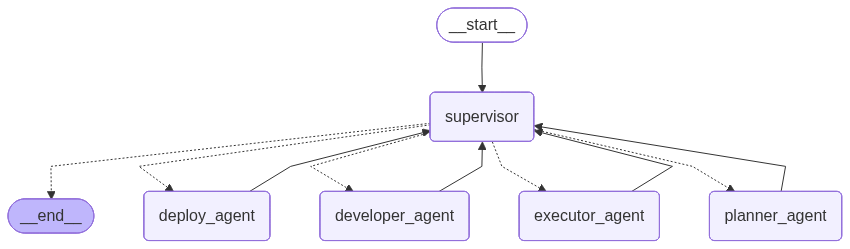

In [9]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))